importing the libraries

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

reading the data from cvs file

In [4]:
teams = pd.read_csv(r"C:\Users\LOQ\Desktop\IT\AI course\Data\teams.csv")

we don't need all the columns in this data

In [5]:
teams

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0,0.0,0.0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0,0.0,0.0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0,0.0,0.0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0,0.0,0.0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,19,26,25.0,179.0,71.1,0,0.0,0.0
2140,ZIM,Zimbabwe,2004,11,14,25.1,177.8,70.5,3,0.0,0.0
2141,ZIM,Zimbabwe,2008,15,16,26.1,171.9,63.7,4,3.0,1.0
2142,ZIM,Zimbabwe,2012,8,9,27.3,174.4,65.2,0,4.0,2.3


this data have 2144 record and 11 feature


In [6]:
teams.describe()

,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
count,2144.000000,2144.000000,2144.000000,2144.000000,2144.000000,2144.000000,2144.000000,2014.000000,2014.000000
mean,1994.507463,35.724813,73.693097,24.778591,173.900233,69.271595,10.556437,10.248759,9.449901
std,15.384205,49.490270,127.907577,2.808559,5.357367,7.606507,33.028143,31.951920,28.232227
min,1964.000000,1.000000,1.000000,17.000000,151.000000,43.000000,0.000000,0.000000,0.000000
25%,1984.000000,6.000000,7.000000,23.275000,170.500000,64.500000,0.000000,0.000000,0.000000
50%,1996.000000,13.000000,19.000000,24.700000,174.400000,69.400000,0.000000,0.000000,0.300000
75%,2008.000000,44.000000,70.250000,26.100000,177.300000,73.400000,4.000000,4.000000,4.650000
max,2016.000000,270.000000,839.000000,66.000000,193.000000,148.000000,442.000000,442.000000,314.000000


In [7]:
teams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2144 entries, 0 to 2143
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   team           2144 non-null   object 
 1   country        2144 non-null   object 
 2   year           2144 non-null   int64  
 3   events         2144 non-null   int64  
 4   athletes       2144 non-null   int64  
 5   age            2144 non-null   float64
 6   height         2144 non-null   float64
 7   weight         2144 non-null   float64
 8   medals         2144 non-null   int64  
 9   prev_medals    2014 non-null   float64
 10  prev_3_medals  2014 non-null   float64
dtypes: float64(5), int64(4), object(2)
memory usage: 184.4+ KB


edit this data ... we only need some feature to deal with

In [8]:
teams = teams[["team","country","year","athletes","age","prev_medals","medals"]]

In [9]:
teams

,team,country,year,athletes,age,prev_medals,medals
0,AFG,Afghanistan,1964,8,22.0,0.0,0
1,AFG,Afghanistan,1968,5,23.2,0.0,0
2,AFG,Afghanistan,1972,8,29.0,0.0,0
3,AFG,Afghanistan,1980,11,23.6,0.0,0
4,AFG,Afghanistan,2004,5,18.6,0.0,0
...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,26,25.0,0.0,0
2140,ZIM,Zimbabwe,2004,14,25.1,0.0,3
2141,ZIM,Zimbabwe,2008,16,26.1,3.0,4
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0


In [10]:
teams = teams.dropna()
print(teams)

     team      country  year  athletes   age  prev_medals  medals
0     AFG  Afghanistan  1964         8  22.0          0.0       0
1     AFG  Afghanistan  1968         5  23.2          0.0       0
2     AFG  Afghanistan  1972         8  29.0          0.0       0
3     AFG  Afghanistan  1980        11  23.6          0.0       0
4     AFG  Afghanistan  2004         5  18.6          0.0       0
...   ...          ...   ...       ...   ...          ...     ...
2139  ZIM     Zimbabwe  2000        26  25.0          0.0       0
2140  ZIM     Zimbabwe  2004        14  25.1          0.0       3
2141  ZIM     Zimbabwe  2008        16  26.1          3.0       4
2142  ZIM     Zimbabwe  2012         9  27.3          4.0       0
2143  ZIM     Zimbabwe  2016        31  27.5          0.0       0

[2014 rows x 7 columns]


we need to find the features that will help us to predict the medals

In [11]:
teams.describe()

,year,athletes,age,prev_medals,medals
count,2014.000000,2014.000000,2014.000000,2014.000000,2014.000000
mean,1995.227408,76.329692,24.812612,10.248759,10.990070
std,15.227727,129.799427,2.758258,31.951920,33.627528
min,1964.000000,1.000000,17.000000,0.000000,0.000000
25%,1984.000000,7.000000,23.300000,0.000000,0.000000
50%,1996.000000,21.000000,24.700000,0.000000,0.000000
75%,2008.000000,74.750000,26.100000,4.000000,5.000000
max,2016.000000,839.000000,66.000000,442.000000,442.000000


In [12]:
print(teams[["year","athletes", "age","prev_medals","medals"]].corr()["medals"])

year          -0.034870
athletes       0.839909
age            0.023231
prev_medals    0.920048
medals         1.000000
Name: medals, dtype: float64


the target is "medals" feature and we need to find the features that will help me to predict the target

we see that the "prev_medals" and "athletes" have very high positive-correlation value so we can use them to predict the target

now lets split the data to training and testing data
but in our case :
we should take the every thing after year=2012 for example for testing

and every year less than 2012 it will be for training

because we should depend on the past to predict the future values

In [13]:
train = teams[teams["year"] < 2012].copy()
test = teams[teams["year"] >= 2012].copy()

In [14]:
train

,team,country,year,athletes,age,prev_medals,medals
0,AFG,Afghanistan,1964,8,22.0,0.0,0
1,AFG,Afghanistan,1968,5,23.2,0.0,0
2,AFG,Afghanistan,1972,8,29.0,0.0,0
3,AFG,Afghanistan,1980,11,23.6,0.0,0
4,AFG,Afghanistan,2004,5,18.6,0.0,0
...,...,...,...,...,...,...,...
2137,ZIM,Zimbabwe,1992,28,21.2,0.0,0
2138,ZIM,Zimbabwe,1996,21,23.8,0.0,0
2139,ZIM,Zimbabwe,2000,26,25.0,0.0,0
2140,ZIM,Zimbabwe,2004,14,25.1,0.0,3


In [15]:
test

,team,country,year,athletes,age,prev_medals,medals
6,AFG,Afghanistan,2012,6,24.8,1.0,1
7,AFG,Afghanistan,2016,3,24.7,1.0,0
24,ALB,Albania,2012,10,25.7,0.0,0
25,ALB,Albania,2016,6,23.7,0.0,0
37,ALG,Algeria,2012,39,24.8,2.0,1
...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,19.3,0.0,0
2131,ZAM,Zambia,2012,7,22.6,0.0,0
2132,ZAM,Zambia,2016,7,24.1,0.0,0
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0


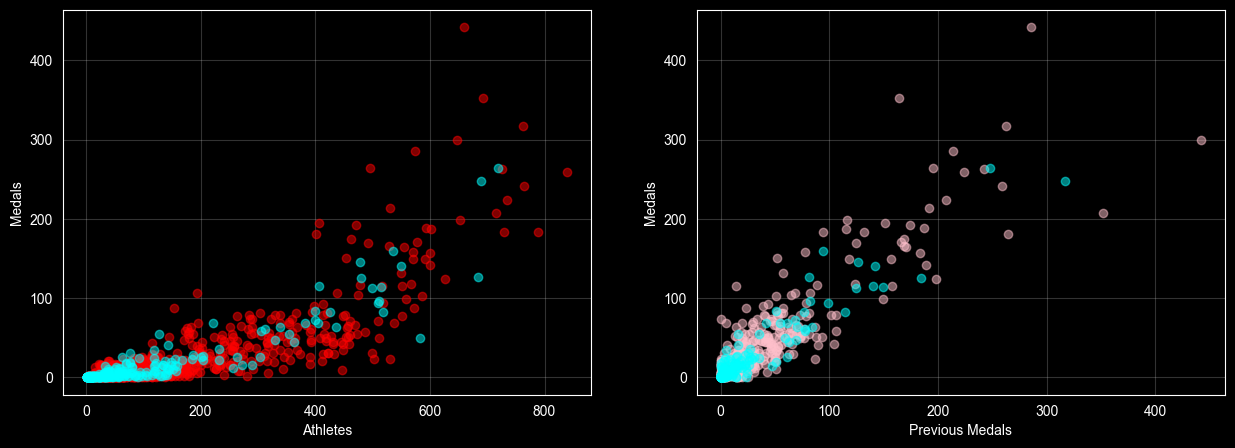

In [23]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.scatter(train["athletes"], train["medals"],color="red",alpha=0.5,label="train")
plt.scatter(test["athletes"], test["medals"],color="cyan",alpha=0.5,label="test")
plt.grid(True,alpha=0.2)
plt.xlabel("Athletes")
plt.ylabel("Medals")

plt.subplot(1,2,2)
plt.scatter(train["prev_medals"], train["medals"],color="pink", alpha=0.5,label="train")
plt.scatter(test["prev_medals"], test["medals"],color="cyan", alpha=0.5,label="test")
plt.grid(True,alpha=0.2)
plt.xlabel("Previous Medals")
plt.ylabel("Medals")


plt.show()

after we understand the data we should start build our model

In [24]:
model = LinearRegression()
predictors = ["athletes","prev_medals"] # x feature
target = ["medals"] # y target
model.fit(train[predictors],train[target])

# because we have 2 features so we in 3d space and line convert to a plane in the space y = w1x1 + w2x2 + b

print("slop : " , model.coef_[0])
print("intercept : " , model.intercept_)
# finish training

predictions = model.predict(test[predictors])
print(predictions)

slop :  [0.07170379 0.75062549]
intercept :  [-2.14206946]
[[-9.61221245e-01]
 [-1.17633261e+00]
 [-1.42503158e+00]
 [-1.71184673e+00]
 [ 2.15562926e+00]
 [ 3.91463636e+00]
 [-1.71184673e+00]
 [-1.85525431e+00]
 [ 3.67563128e-01]
 [-2.77770967e-01]
 [-1.85525431e+00]
 [-1.49673537e+00]
 [ 4.67519911e+01]
 [ 2.87550937e+01]
 [ 4.58450091e+00]
 [ 2.54773581e+00]
 [-1.85525431e+00]
 [-1.64014295e+00]
 [-1.85525431e+00]
 [-1.85525431e+00]
 [ 1.46556876e+02]
 [ 1.20571799e+02]
 [ 6.56314795e+00]
 [ 3.95275254e+00]
 [ 7.34283247e+00]
 [ 1.03117468e+01]
 [ 5.19171882e+00]
 [ 3.58517645e+00]
 [-1.64014295e+00]
 [-1.64014295e+00]
 [-1.56843916e+00]
 [-1.20992022e+00]
 [-1.71184673e+00]
 [-1.42503158e+00]
 [ 1.17929959e+01]
 [ 1.00049298e+01]
 [-1.78355052e+00]
 [-1.71184673e+00]
 [-1.56843916e+00]
 [-1.56843916e+00]
 [-1.99866189e+00]
 [-1.99866189e+00]
 [-1.56843916e+00]
 [-1.35332779e+00]
 [-1.92695810e+00]
 [-1.92695810e+00]
 [ 3.28912706e+01]
 [ 2.53042547e+01]
 [-1.78355052e+00]
 [-1.28162

we notice that the predictions for the medals have 2 main problems : 1. not rounded, 2. have negative value

In [25]:
predictions = predictions.round()
for i in range(len(predictions)):
    if predictions[i] < 0:
        predictions[i] = abs(predictions[i])
        predictions[i]=0
print(predictions)

[[  0.]
 [  0.]
 [  0.]
 [  0.]
 [  2.]
 [  4.]
 [  0.]
 [  0.]
 [  0.]
 [ -0.]
 [  0.]
 [  0.]
 [ 47.]
 [ 29.]
 [  5.]
 [  3.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [147.]
 [121.]
 [  7.]
 [  4.]
 [  7.]
 [ 10.]
 [  5.]
 [  4.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [ 12.]
 [ 10.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [ 33.]
 [ 25.]
 [  0.]
 [  0.]
 [  0.]
 [ -0.]
 [ 78.]
 [ 84.]
 [  0.]
 [  1.]
 [  0.]
 [  0.]
 [  7.]
 [  4.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [ 50.]
 [ 68.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  2.]
 [  1.]
 [170.]
 [127.]
 [  0.]
 [  0.]
 [  1.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  8.]
 [ 15.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [ 10.]
 [ 31.]
 [ 42.]
 [ 19.]
 [  0.]
 [  0.]
 [ 15.]
 [ 18.]
 [ 23.]
 [ 20.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  2.]
 [  2.]
 [  1.]
 [  1.]
 [  8.]
 [  9.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [ 75.]
 [ 71.]
 [  3.]
 [  3.]
 [  6.]
 [  6.]
 [  0.]


add the predictions as new column in the test data to compare the real value and the predicted value
by looking


In [26]:
test["predictions"] = predictions
test

,team,country,year,athletes,age,prev_medals,medals,predictions
6,AFG,Afghanistan,2012,6,24.8,1.0,1,0.0
7,AFG,Afghanistan,2016,3,24.7,1.0,0,0.0
24,ALB,Albania,2012,10,25.7,0.0,0,0.0
25,ALB,Albania,2016,6,23.7,0.0,0,0.0
37,ALG,Algeria,2012,39,24.8,2.0,1,2.0
...,...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,19.3,0.0,0,0.0
2131,ZAM,Zambia,2012,7,22.6,0.0,0,0.0
2132,ZAM,Zambia,2016,7,24.1,0.0,0,0.0
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0,2.0


In [27]:
test[test["team"]=="ARG"]

,team,country,year,athletes,age,prev_medals,medals,predictions
80,ARG,Argentina,2012,148,27.4,51.0,19,47.0
81,ARG,Argentina,2016,232,27.5,19.0,22,29.0


|now we should discover if this model in good or not ?

In [28]:
error_abs = mean_absolute_error(test["medals"],test["predictions"])
error_abs

3.2987654320987656

lets try to find the R-squared for this model


In [29]:
R_squared = mean_squared_error(test["medals"],test["predictions"])
R_squared

65.42222222222222